In [150]:
%reload_ext autoreload
%autoreload 2

In [151]:
# 1. Verificação e Instalação Automática
try:
    import pandas, sklearn, matplotlib
except ImportError:
    print("Dependências ausentes. Iniciando instalação automatizada...")
    %pip install pandas scikit-learn matplotlib
    print("Ambiente configurado com sucesso.")

# 2. Imports de Bibliotecas Base
import pandas as pd
import matplotlib.pyplot as plt

# 3. Imports do Scikit-Learn (Modelagem e Avaliação)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configurações de exibição (Opcional, mas ajuda no Jupyter)
%matplotlib inline

In [ ]:
from diabetes import executar_experimento, EXP_PROFISSIONAL, EXP_ACADEMICO, plotar_resultados

In [152]:
df_diabetes = pd.read_csv('diabetes.csv')

In [153]:
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:


df_diabetes.rename(columns=traducao, inplace=True)

In [155]:
df_diabetes.head()

,Gravidez,Glicose,Pressao,Pele,Insulina,IMC,Historico,Idade,Resultado
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [156]:
# 2. Definição de Features (X) e Target (y)
X = df_diabetes.drop('Resultado', axis=1)
y = df_diabetes['Resultado']

In [157]:
# 3. Configuração dos Experimentos (Variação de Profundidade)
configuracoes = [
    {"crit": "gini", "depth": 3, "label": "Gini / Prof. 3"},
    {"crit": "gini", "depth": 5, "label": "Gini / Prof. 5"},
    {"crit": "entropy", "depth": 3, "label": "Entropia / Prof. 3"},
    {"crit": "entropy", "depth": 5, "label": "Entropia / Prof. 5"}
]

resultados = []

In [158]:
# 4. Loop de Execução dos Modelos
for conf in configuracoes:
    # Divisão dos dados
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
    
    # Instanciação e Treino com a variação de critério
    clf = DecisionTreeClassifier(criterion=conf["crit"], max_depth=conf["depth"], random_state=1)
    clf.fit(X_train, y_train)

    # Predição
    y_pred = clf.predict(X_test)
    
    # Cálculo das métricas
    res = {
        "Config": conf["label"],
        "Acurácia": metrics.accuracy_score(y_test, y_pred),
        "Precisão": metrics.precision_score(y_test, y_pred),
        "Recall": metrics.recall_score(y_test, y_pred),
        "F1-Score": metrics.f1_score(y_test, y_pred)
    }
    resultados.append(res)

In [166]:
# 5. Transformação dos resultados para visualização
df_res = pd.DataFrame(resultados).set_index("Config")

In [ ]:
plotar_comparativo(df_prof, 
                   titulo='Comparativo de Métricas: Gini vs Entropia por Profundidade', 
                   eixo_x='Configurações do Modelo (Profundidade)')


In [ ]:
plotar_comparativo(df_acad, 
                   titulo='Comparativo de Métricas: Variações da Árvore de Decisão (Diabetes)', 
                   eixo_x='Configurações (Critério / Split)')

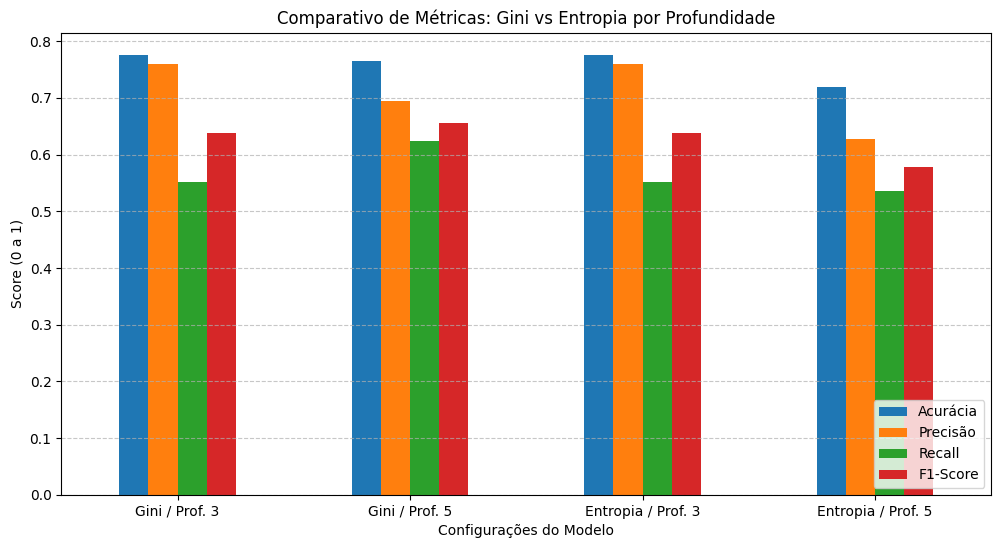

In [ ]:
# 6. Plotagem dos Resultados (Gráfico de Barras)
ax = df_res.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Comparativo de Métricas: Gini vs Entropia por Profundidade')
plt.ylabel('Score (0 a 1)')
plt.xlabel('Configurações do Modelo')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


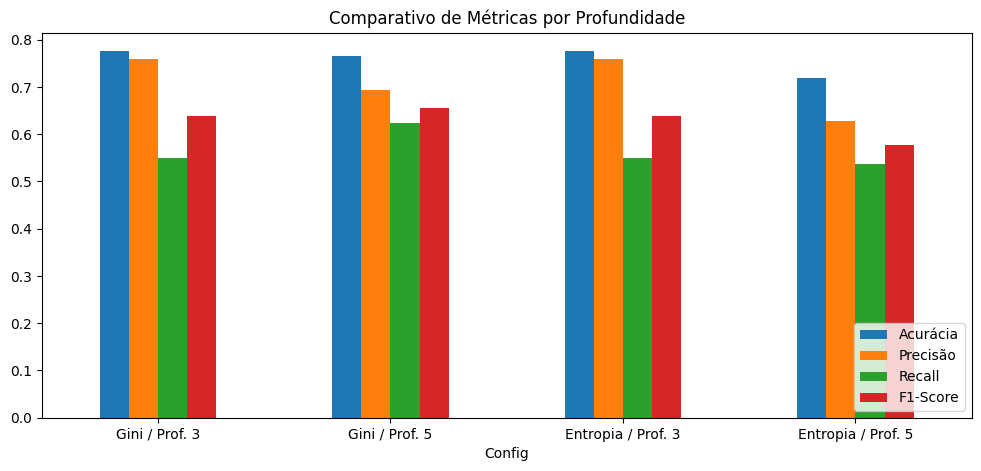

In [ ]:
# 6. Plotagem dos Resultados (Gráfico de Barras)
ax = df_res.plot(kind='bar', figsize=(12, 5), rot=0).legend(loc='lower right')
plt.title('Comparativo de Métricas por Profundidade (Diabetes)')
plt.show()

ax = df_res.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Comparativo de Métricas: Variações da Árvore de Decisão (Diabetes)')
plt.ylabel('Score (0 a 1)')
plt.xlabel('Configurações (Critério / Split)')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [160]:
# 5. Transformação dos resultados para visualização
df_res = pd.DataFrame(resultados).set_index("Config")

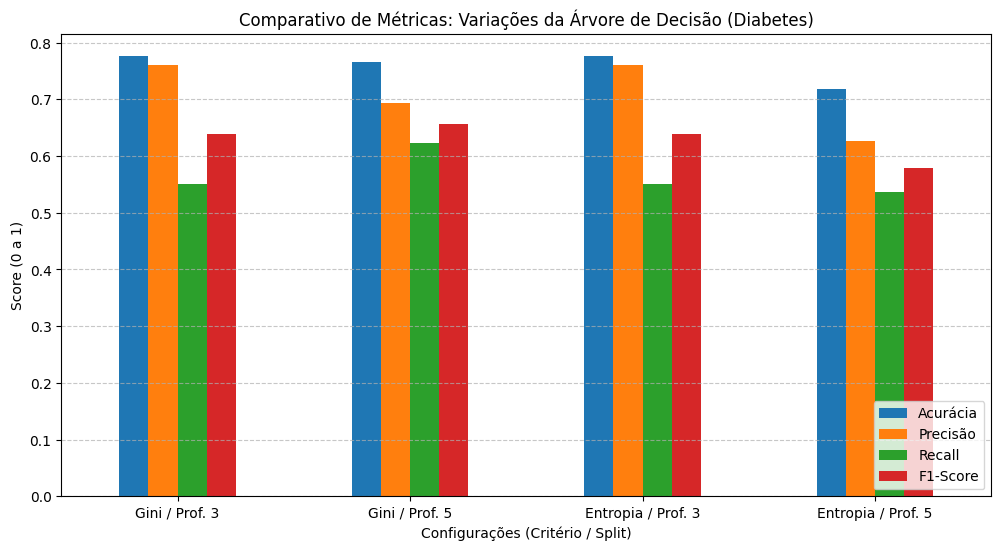

In [161]:
# 6. Plotagem dos Resultados (Gráfico de Barras)
ax = df_res.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Comparativo de Métricas: Variações da Árvore de Decisão (Diabetes)')
plt.ylabel('Score (0 a 1)')
plt.xlabel('Configurações (Critério / Split)')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [162]:
# 6. Exibição da tabela de resultados
print("\n--- Tabela de Resultados ---")
print(df_res)


--- Tabela de Resultados ---
                    Acurácia  Precisão    Recall  F1-Score
Config                                                    
Gini / Prof. 3      0.776042  0.760000  0.550725  0.638655
Gini / Prof. 5      0.765625  0.693548  0.623188  0.656489
Entropia / Prof. 3  0.776042  0.760000  0.550725  0.638655
Entropia / Prof. 5  0.718750  0.627119  0.536232  0.578125



Visualizando detalhes para a configuração: Entropia / Prof. 5


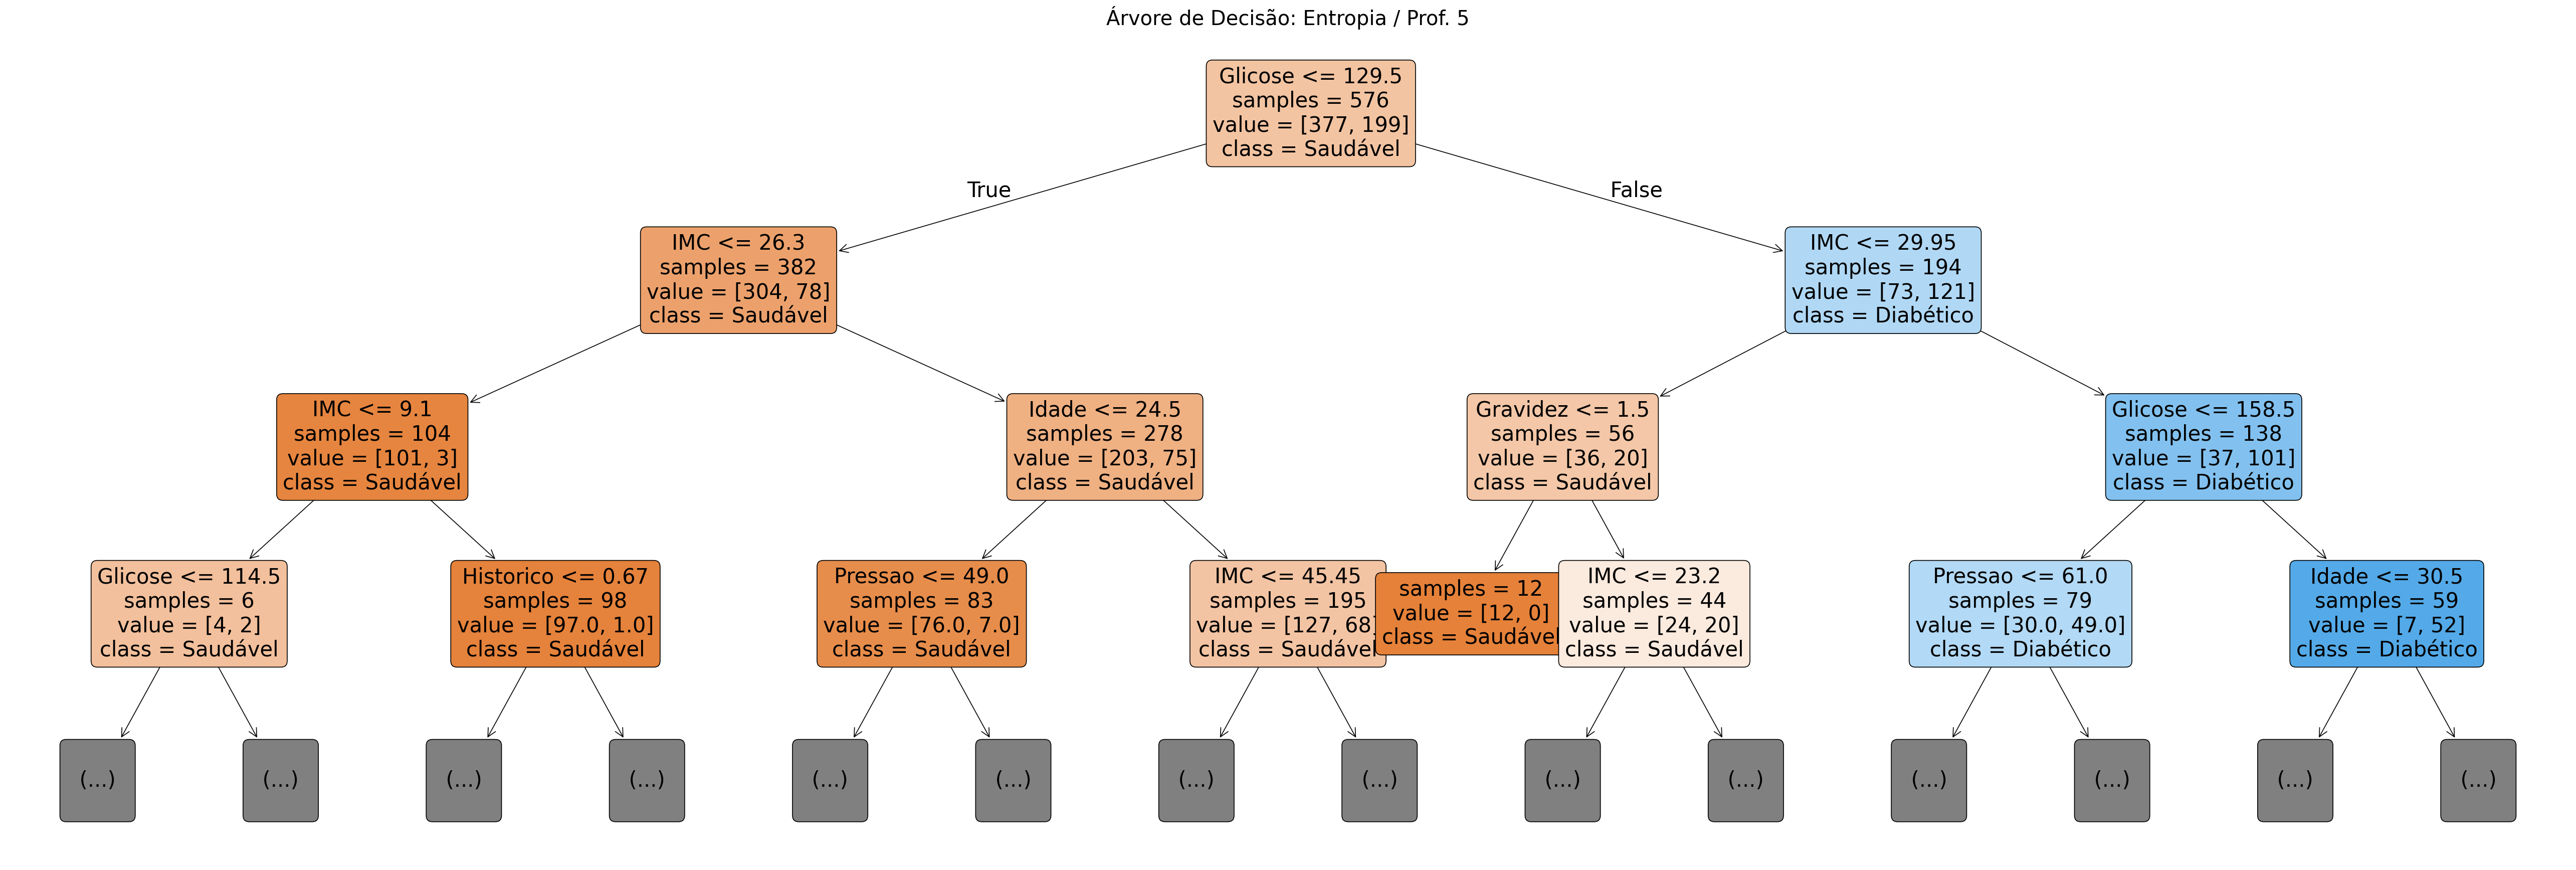

In [163]:

# 7. Visualização Detalhada (do ÚLTIMO modelo treinado no loop)

print(f"\nVisualizando detalhes para a configuração: {conf['label']}")

plt.figure(figsize=(55, 18), dpi=120) 
plot_tree(clf, 
          feature_names=X.columns,  
          class_names=['Saudável', 'Diabético'],
          filled=True, 
          rounded=True,
          max_depth=3,
          fontsize=25,      
          precision=2,
          impurity=False) 
plt.title(f"Árvore de Decisão: {conf['label']}", fontsize=24)
plt.show()


In [ ]:
from diabetes import visualizar_arvore_decisao

# Para cada configuração testada, mostramos a árvore correspondente
for nome_config, linha in df_res_prof.iterrows():
    visualizar_arvore_decisao(
        modelo=linha['modelo'], 
        nomes_colunas=X.columns, 
        titulo_config=nome_config
    )


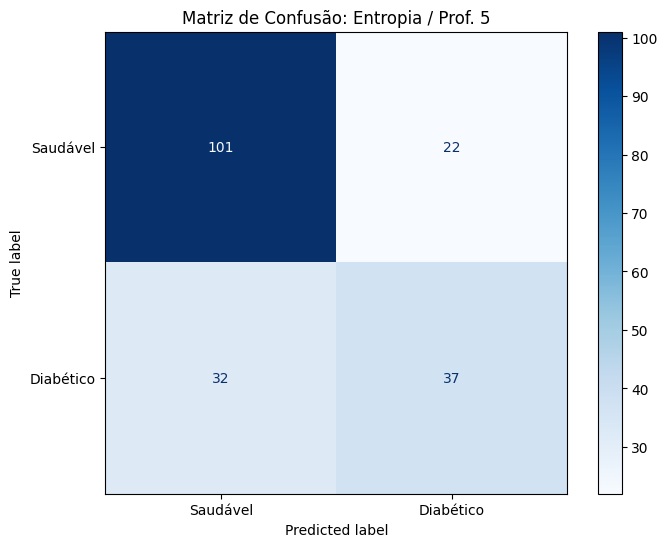

In [164]:
# 8. Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Diabético'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f"Matriz de Confusão: {conf['label']}")
plt.show()

In [ ]:
from diabetes import plotar_matriz_confusao

# Exemplo usando os dados do DataFrame de resultados (df_res)
linha_teste = df_res_prof.iloc[0] # Pega a primeira configuração

plotar_matriz_confusao(
    y_real=linha_teste['y_test'], 
    y_previsto=linha_teste['y_pred'], 
    titulo_config=linha_teste.name
)


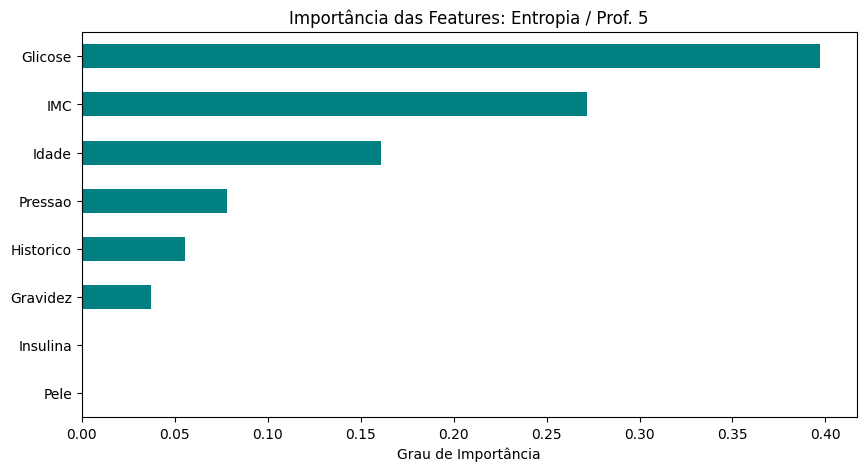

In [165]:
# 9. Importância das Features
plt.figure(figsize=(10, 5))
importancias = pd.Series(clf.feature_importances_, index=X.columns)
importancias.sort_values().plot(kind='barh', color='teal')
plt.title(f"Importância das Features: {conf['label']}")
plt.xlabel("Grau de Importância")
plt.show()
